In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics.pairwise import cosine_distances

# ---------------------------------------------------------
# 1. Load Real Online Dataset (LFW)
# ---------------------------------------------------------
print("Downloading Labeled Faces in the Wild (LFW) dataset...")
# We only load people who have at least 2 images (so we can have an Anchor and a Positive)
lfw = fetch_lfw_people(min_faces_per_person=2, color=True)

images = lfw.images
labels = lfw.target
target_names = lfw.target_names

print(f"Loaded {len(images)} images of {len(target_names)} people.")

# ---------------------------------------------------------
# 2. Preprocess Images to 160x160 for FaceNet
# ---------------------------------------------------------
def preprocess_dataset(imgs):
    processed = []
    for img in imgs:
        # Resize to match our model's expected input
        resized = cv2.resize(img, (160, 160))
        # Ensure it is normalized between 0 and 1
        if resized.max() > 1.0:
            resized = resized / 255.0
        processed.append(resized)
    return np.array(processed, dtype='float32')

X_data = preprocess_dataset(images)

# ---------------------------------------------------------
# 3. Generate Real Triplets
# ---------------------------------------------------------
def generate_real_triplets(X, y, num_triplets=300):
    """Creates Anchor, Positive, and Negative sets from the LFW dataset."""
    anchors, positives, negatives = [], [], []
    unique_classes = np.unique(y)

    for _ in range(num_triplets):
        # 1. Pick a random person for Anchor & Positive
        pos_class = np.random.choice(unique_classes)
        pos_indices = np.where(y == pos_class)[0]

        # We need at least 2 images for this person
        if len(pos_indices) < 2:
            continue

        a_idx, p_idx = np.random.choice(pos_indices, 2, replace=False)

        # 2. Pick a DIFFERENT person for Negative
        neg_class = np.random.choice(np.setdiff1d(unique_classes, [pos_class]))
        neg_indices = np.where(y == neg_class)[0]
        n_idx = np.random.choice(neg_indices)

        anchors.append(X[a_idx])
        positives.append(X[p_idx])
        negatives.append(X[n_idx])

    return [np.array(anchors), np.array(positives), np.array(negatives)]

print("Creating training triplets...")
real_triplets = generate_real_triplets(X_data, labels, num_triplets=500)

# ---------------------------------------------------------
# 4. Train the Model
# ---------------------------------------------------------
print("Training Siamese Network on LFW Dataset...")
siamese_model.fit(
    x=real_triplets,
    y=np.zeros(len(real_triplets[0])), # Labels are 0 because loss is handled internally
    epochs=10,
    batch_size=16,
    verbose=1
)
print("Training Complete!")

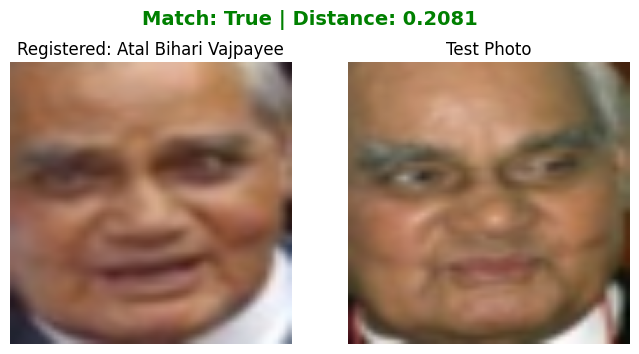

In [3]:
# ---------------------------------------------------------
# 5. Test 1:1 Verification on a Single Person
# ---------------------------------------------------------
# Pick the first person in our dataset
test_person_id = labels[0]
test_person_name = target_names[test_person_id]

# Find all images of this person
person_indices = np.where(labels == test_person_id)[0]

# We will use the first image to "register" them in the database
# We will use the second image as the "mystery photo" to identify
img1 = X_data[person_indices[0]]
img2 = X_data[person_indices[1]]

# Extract 128-D embeddings using the base model
emb1 = base_model.predict(np.expand_dims(img1, 0), verbose=0)[0]
emb2 = base_model.predict(np.expand_dims(img2, 0), verbose=0)[0]

# Calculate the distance
distance = cosine_distances([emb1], [emb2])[0][0]

# Determine if it's a match (threshold usually between 0.4 and 0.6)
threshold = 0.5
is_match = distance < threshold

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img1)
axes[0].set_title(f"Registered: {test_person_name}")
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title("Test Photo")
axes[1].axis('off')

plt.suptitle(f"Match: {is_match} | Distance: {distance:.4f}",
             color="green" if is_match else "red", fontsize=14, weight='bold')
plt.show()

OpenCV DNN found 5 face(s).


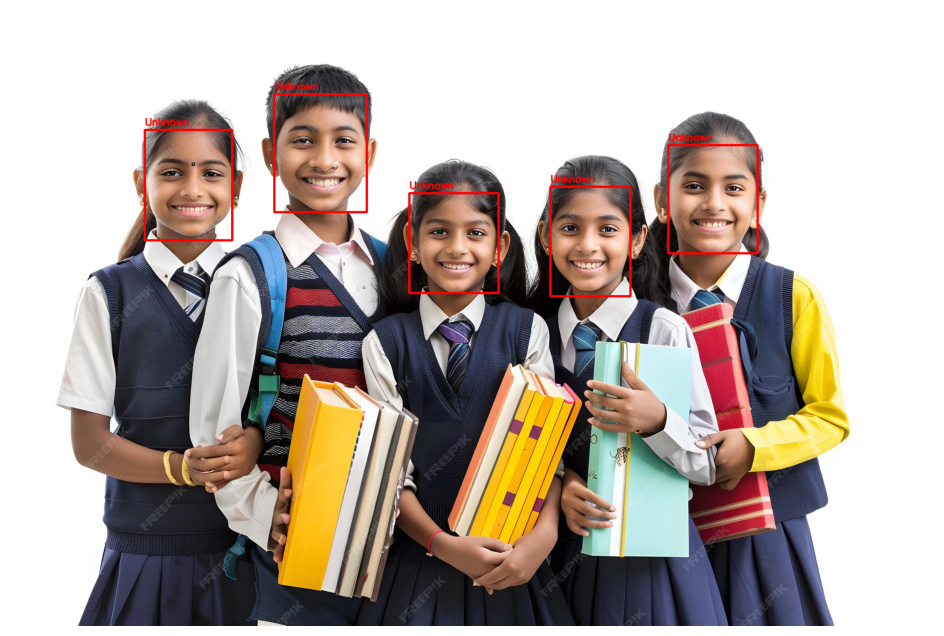

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import urllib.request
import os

# ---------------------------------------------------------
# 1. Auto-Download OpenCV's Deep Learning Face Detector
# ---------------------------------------------------------
# This bypasses all MTCNN and MediaPipe installation errors!
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

prototxt_path = "deploy.prototxt"
model_path = "res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(prototxt_path):
    print("Downloading OpenCV DNN prototxt...")
    urllib.request.urlretrieve(prototxt_url, prototxt_path)
if not os.path.exists(model_path):
    print("Downloading OpenCV DNN model...")
    urllib.request.urlretrieve(model_url, model_path)

# Load the network into memory
dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

def detect_faces_dnn(image_rgb, confidence_threshold=0.5):
    """Uses OpenCV's built-in Deep Learning model to find faces."""
    h, w = image_rgb.shape[:2]
    # Convert image to a blob for the neural network
    blob = cv2.dnn.blobFromImage(cv2.resize(image_rgb, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []

    # Loop over all detections
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        # Filter out weak detections (like the books!)
        if confidence > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            # Ensure the bounding boxes fall within the dimensions of the frame
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w, endX), min(h, endY)

            # Append as (x, y, width, height) to match our previous logic
            boxes.append((startX, startY, endX - startX, endY - startY))

    return boxes

# ---------------------------------------------------------
# 2. Simplified FaceNet Model (From your Lab)
# ---------------------------------------------------------
def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(64, (5,5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(embedding_size, activation=None)(x)
    embeddings = layers.Lambda(lambda tensor: tf.math.l2_normalize(tensor, axis=1))(x)

    return keras.Model(inputs, embeddings, name='Custom_FaceNet')

base_model = build_custom_facenet()

# ---------------------------------------------------------
# 3. Database Registration
# ---------------------------------------------------------
known_database = {}

def register_user(name, image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb)

    if not boxes:
        print(f"No face detected in {image_path} to register.")
        return

    x, y, w, h = boxes[0]

    # Add a small margin for alignment
    margin = int(min(w, h) * 0.1)
    x1, y1 = max(0, x - margin), max(0, y - margin)
    x2, y2 = min(img_rgb.shape[1], x + w + margin), min(img_rgb.shape[0], y + h + margin)

    face_crop = img_rgb[y1:y2, x1:x2]
    face_resized = cv2.resize(face_crop, (160, 160))
    face_normalized = face_resized.astype('float32') / 255.0

    emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]
    known_database[name] = emb
    print(f"Successfully registered: {name}")

# ---------------------------------------------------------
# 4. Multi-Face Recognition Logic
# ---------------------------------------------------------
def process_group_photo(image_path, threshold=0.5):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb)
    print(f"OpenCV DNN found {len(boxes)} face(s).")

    for (x, y, w, h) in boxes:
        margin = int(min(w, h) * 0.1)
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img_rgb.shape[1], x + w + margin), min(img_rgb.shape[0], y + h + margin)

        face_crop = img_rgb[y1:y2, x1:x2]
        if face_crop.size == 0: continue

        face_resized = cv2.resize(face_crop, (160, 160))
        face_normalized = face_resized.astype('float32') / 255.0

        emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]

        label = "Unknown"
        color = (255, 0, 0) # Red for unknown
        best_dist = float('inf')

        if known_database:
            distances = cosine_distances([emb], list(known_database.values()))[0]
            min_idx = np.argmin(distances)
            min_dist = distances[min_idx]

            if min_dist < threshold:
                label = list(known_database.keys())[min_idx]
                color = (0, 255, 0) # Green for match
                best_dist = min_dist

        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)
        text = f"{label} ({best_dist:.2f})" if label != "Unknown" else label
        cv2.putText(img_rgb, text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# =========================================================
# 5. Execute the Lab
# =========================================================
if __name__ == "__main__":
    known_database.clear()

    # 1. Provide the exact path to your uploaded image here:
    test_image = "group_photo.jpg"

    # 2. Run the detection!
    process_group_photo(test_image, threshold=0.5)

Found 3 face(s). Analyzing emotions...


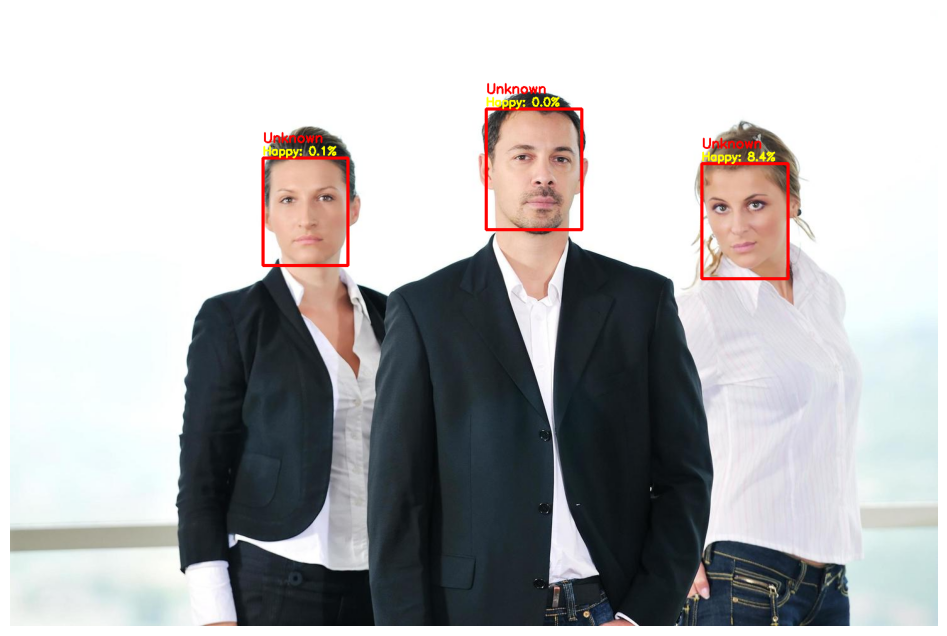

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import urllib.request
import os
from deepface import DeepFace # NEW: Import DeepFace for emotion

# ---------------------------------------------------------
# 1. OpenCV DNN Face Detector (Unchanged & Error-Free)
# ---------------------------------------------------------
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

prototxt_path = "deploy.prototxt"
model_path = "res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(prototxt_path):
    urllib.request.urlretrieve(prototxt_url, prototxt_path)
if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

def detect_faces_dnn(image_rgb, confidence_threshold=0.5):
    h, w = image_rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image_rgb, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w, endX), min(h, endY)
            boxes.append((startX, startY, endX - startX, endY - startY))
    return boxes

# ---------------------------------------------------------
# 2. Simplified FaceNet Model (Unchanged)
# ---------------------------------------------------------
def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, (5,5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(embedding_size, activation=None)(x)
    embeddings = layers.Lambda(lambda tensor: tf.math.l2_normalize(tensor, axis=1))(x)
    return keras.Model(inputs, embeddings, name='Custom_FaceNet')

base_model = build_custom_facenet()
known_database = {}

# ---------------------------------------------------------
# 3. Multi-Face Recognition + HAPPINESS MEASUREMENT
# ---------------------------------------------------------
def process_group_photo_with_emotions(image_path, threshold=0.5):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb)
    print(f"Found {len(boxes)} face(s). Analyzing emotions...")

    for (x, y, w, h) in boxes:
        margin = int(min(w, h) * 0.1)
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img_rgb.shape[1], x + w + margin), min(img_rgb.shape[0], y + h + margin)

        face_crop = img_rgb[y1:y2, x1:x2]
        if face_crop.size == 0: continue

        # --- NEW: Measure Happiness using DeepFace ---
        try:
            # enforce_detection=False prevents errors since we already cropped the face
            analysis = DeepFace.analyze(face_crop, actions=['emotion'], enforce_detection=False)
            # DeepFace returns a list of dictionaries, we just need the first one
            if isinstance(analysis, list):
                analysis = analysis[0]
            # Extract the 'happy' percentage (0 to 100)
            happiness_score = analysis['emotion']['happy']
        except Exception as e:
            happiness_score = 0.0
        # ---------------------------------------------

        # Extract identity embedding
        face_resized = cv2.resize(face_crop, (160, 160))
        face_normalized = face_resized.astype('float32') / 255.0
        emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]

        label = "Unknown"
        color = (255, 0, 0) # Red for unknown
        best_dist = float('inf')

        if known_database:
            distances = cosine_distances([emb], list(known_database.values()))[0]
            min_idx = np.argmin(distances)
            min_dist = distances[min_idx]
            if min_dist < threshold:
                label = list(known_database.keys())[min_idx]
                color = (0, 255, 0) # Green for match
                best_dist = min_dist

        # Draw bounding box
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)

        # Add Identity Text
        id_text = f"{label} ({best_dist:.2f})" if label != "Unknown" else label
        cv2.putText(img_rgb, id_text, (x, y-25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Add Happiness Text (Yellow color for visibility)
        happy_text = f"Happy: {happiness_score:.1f}%"
        cv2.putText(img_rgb, happy_text, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# =========================================================
# 4. Execute the Lab
# =========================================================
if __name__ == "__main__":
    known_database.clear()
    test_image = "group_photo(1).jpg"
    process_group_photo_with_emotions(test_image, threshold=0.5)

Found 5 face(s). Analyzing emotions...


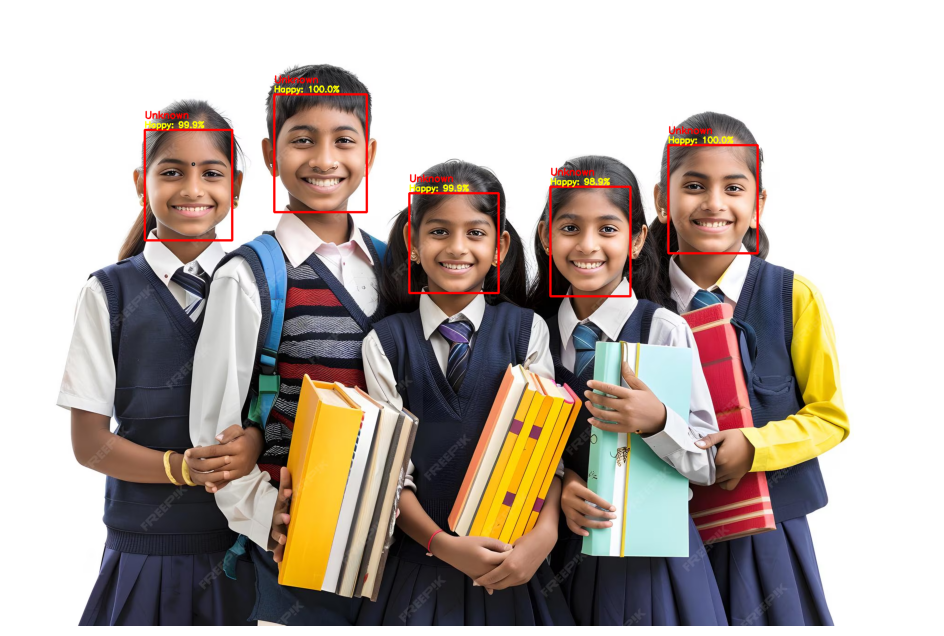

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import urllib.request
import os
from deepface import DeepFace # NEW: Import DeepFace for emotion

# ---------------------------------------------------------
# 1. OpenCV DNN Face Detector (Unchanged & Error-Free)
# ---------------------------------------------------------
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

prototxt_path = "deploy.prototxt"
model_path = "res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(prototxt_path):
    urllib.request.urlretrieve(prototxt_url, prototxt_path)
if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)

def detect_faces_dnn(image_rgb, confidence_threshold=0.5):
    h, w = image_rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image_rgb, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w, endX), min(h, endY)
            boxes.append((startX, startY, endX - startX, endY - startY))
    return boxes

# ---------------------------------------------------------
# 2. Simplified FaceNet Model (Unchanged)
# ---------------------------------------------------------
def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, (5,5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(embedding_size, activation=None)(x)
    embeddings = layers.Lambda(lambda tensor: tf.math.l2_normalize(tensor, axis=1))(x)
    return keras.Model(inputs, embeddings, name='Custom_FaceNet')

base_model = build_custom_facenet()
known_database = {}

# ---------------------------------------------------------
# 3. Multi-Face Recognition + HAPPINESS MEASUREMENT
# ---------------------------------------------------------
def process_group_photo_with_emotions(image_path, threshold=0.5):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb)
    print(f"Found {len(boxes)} face(s). Analyzing emotions...")

    for (x, y, w, h) in boxes:
        margin = int(min(w, h) * 0.1)
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img_rgb.shape[1], x + w + margin), min(img_rgb.shape[0], y + h + margin)

        face_crop = img_rgb[y1:y2, x1:x2]
        if face_crop.size == 0: continue

        # --- NEW: Measure Happiness using DeepFace ---
        try:
            # enforce_detection=False prevents errors since we already cropped the face
            analysis = DeepFace.analyze(face_crop, actions=['emotion'], enforce_detection=False)
            # DeepFace returns a list of dictionaries, we just need the first one
            if isinstance(analysis, list):
                analysis = analysis[0]
            # Extract the 'happy' percentage (0 to 100)
            happiness_score = analysis['emotion']['happy']
        except Exception as e:
            happiness_score = 0.0
        # ---------------------------------------------

        # Extract identity embedding
        face_resized = cv2.resize(face_crop, (160, 160))
        face_normalized = face_resized.astype('float32') / 255.0
        emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]

        label = "Unknown"
        color = (255, 0, 0) # Red for unknown
        best_dist = float('inf')

        if known_database:
            distances = cosine_distances([emb], list(known_database.values()))[0]
            min_idx = np.argmin(distances)
            min_dist = distances[min_idx]
            if min_dist < threshold:
                label = list(known_database.keys())[min_idx]
                color = (0, 255, 0) # Green for match
                best_dist = min_dist

        # Draw bounding box
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 3)

        # Add Identity Text
        id_text = f"{label} ({best_dist:.2f})" if label != "Unknown" else label
        cv2.putText(img_rgb, id_text, (x, y-25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Add Happiness Text (Yellow color for visibility)
        happy_text = f"Happy: {happiness_score:.1f}%"
        cv2.putText(img_rgb, happy_text, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# =========================================================
# 4. Execute the Lab
# =========================================================
if __name__ == "__main__":
    known_database.clear()
    test_image = "group_photo.jpg"
    process_group_photo_with_emotions(test_image, threshold=0.5)